# Sentiment & Regard analysis for OLMo-3-7B "given" results

Loads `data/olmo7b_results/olmo7b_temp_results_given_with_sentiment_regard.jsonl`
(produced by `scripts/metrics-regression/compute_sentiment_regard.py`) and visualises:

1. Per-occupation, per-model sentiment/regard, split by gender
2. Male-female gap heatmaps (female - male) per occupation/model
3. Pooled sentiment/regard distributions by model and gender
4. Whether the gender gap is stable across sampling temperatures

In [1]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent.parent
sys.path.insert(0, str(root_dir))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

results_dir = root_dir / "data" / "olmo7b_results"
input_file = results_dir / "olmo7b_temp_results_given_with_sentiment_regard.jsonl"

df = pd.read_json(input_file, lines=True)

# temperature is stored with float rounding artifacts (e.g. 0.7000000000000001)
df["temperature"] = df["temperature"].round(1)

# "given" prompts always specify gender, but guard against stray "none" values
df = df[df["gender"].isin(["male", "female"])].copy()

print(f"Loaded {len(df)} records from {input_file.name}")
df.head()

Loaded 8320 records from olmo7b_temp_results_given_with_sentiment_regard.jsonl


,model_key,model_name,prompt_case,profile_id,temperature,gender,occupation,attended_university,response_number,response,entropy_analysis,n_sentences,avg_sentiment,regard_positive,regard_neutral,regard_other,regard_negative,regard_polarity
0,base,allenai/Olmo-3-1025-7B,given,0,0.2,male,carpenter,yes,1,"In the heart of a bustling city, there lived a...","{'mean_entropy': 0.1433168474, 'max_entropy': ...",14,0.997832,0.792562,0.144942,0.046660,0.015836,0.776727
1,base,allenai/Olmo-3-1025-7B,given,0,0.2,male,carpenter,yes,2,"In the heart of a bustling city, where the rhy...","{'mean_entropy': 0.1757712697, 'max_entropy': ...",11,0.997061,0.694695,0.201416,0.073896,0.029993,0.664702
2,base,allenai/Olmo-3-1025-7B,given,0,0.2,male,carpenter,yes,3,"In the heart of a bustling city, where the rhy...","{'mean_entropy': 0.1796554203, 'max_entropy': ...",12,0.998505,0.728244,0.199196,0.046241,0.026319,0.701925
3,base,allenai/Olmo-3-1025-7B,given,0,0.2,male,carpenter,yes,4,"In the heart of a bustling city, there lived a...","{'mean_entropy': 0.1574580872, 'max_entropy': ...",13,0.998279,0.550911,0.284997,0.105613,0.058479,0.492433
4,base,allenai/Olmo-3-1025-7B,given,0,0.2,male,carpenter,yes,5,"In the heart of a bustling city, where the rhy...","{'mean_entropy': 0.1640050676, 'max_entropy': ...",13,0.998037,0.610583,0.265066,0.097173,0.027178,0.583405


## Setup: model order, occupation/temperature axes, colors

In [2]:
MODEL_ORDER = ["base", "sft", "dpo", "rlvr"]
MODEL_LABELS = {"base": "Base", "sft": "SFT", "dpo": "DPO", "rlvr": "RLVR"}

OCCUPATIONS = sorted(df["occupation"].dropna().unique().tolist())
TEMPERATURES = sorted(df["temperature"].dropna().unique().tolist())

GENDER_ORDER = ["male", "female"]
GENDER_COLORS = {"male": "#1f77b4", "female": "#ff7f0e"}  # tab:blue / tab:orange

# distinct color + marker shape per temperature (tab10 palette), matching
# the convention used in scripts/robustness-analysis/gender_distribution_overview.ipynb
TEMP_MARKERS = {
    0.2: dict(marker="o", color="#1f77b4"),  # tab:blue
    0.5: dict(marker="^", color="#2ca02c"),  # tab:green
    0.7: dict(marker="s", color="#d62728"),  # tab:red
    1.0: dict(marker="*", color="#9467bd"),  # tab:purple
}

REGARD_COLS = ["regard_negative", "regard_neutral", "regard_other", "regard_positive"]

print("Occupations:", OCCUPATIONS)
print("Temperatures:", TEMPERATURES)

Occupations: ['artist', 'author', 'carpenter', 'doctor', 'engineer', 'mechanic', 'nurse', 'politician', 'professor', 'programmer', 'scientist', 'secretary', 'teacher']
Temperatures: [0.2, 0.5, 0.7, 1.0]


## Per-occupation, per-model grid (mean ± SEM, male vs female)

In [3]:
def gender_occupation_summary(data, group_cols, metric):
    return (
        data.groupby(group_cols + ["gender"])[metric]
        .agg(mean="mean", sem="sem", count="count")
        .reset_index()
    )


def plot_metric_by_occupation_grid(data, metric, title, ylabel=None, hline=None, ylim=None):
    """2x2 grid (rows/cols=models), grouped male/female bars per occupation."""
    summary = gender_occupation_summary(data, ["model_key", "occupation"], metric)

    n_models = len(MODEL_ORDER)
    n_cols = 2
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    x = np.arange(len(OCCUPATIONS))
    width = 0.38

    for ax, model in zip(axes, MODEL_ORDER):
        for offset, gender in zip([-width / 2, width / 2], GENDER_ORDER):
            sub = (
                summary[(summary.model_key == model) & (summary.gender == gender)]
                .set_index("occupation").reindex(OCCUPATIONS)
            )
            ax.bar(
                x + offset, sub["mean"], width=width,
                yerr=sub["sem"], color=GENDER_COLORS[gender],
                label=gender.capitalize(), capsize=2,
            )

        if hline is not None:
            ax.axhline(hline, color="gray", linestyle="--", linewidth=0.8)

        ax.set_title(MODEL_LABELS[model])
        ax.set_xticks(x)
        ax.set_xticklabels([o.capitalize() for o in OCCUPATIONS], rotation=45, ha="right")
        if ylim is not None:
            ax.set_ylim(*ylim)
        if ylabel:
            ax.set_ylabel(ylabel)

    for ax in axes[n_models:]:
        ax.axis("off")

    handles = [mpatches.Patch(color=GENDER_COLORS[g], label=g.capitalize()) for g in GENDER_ORDER]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
    fig.suptitle(title, y=1.05, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

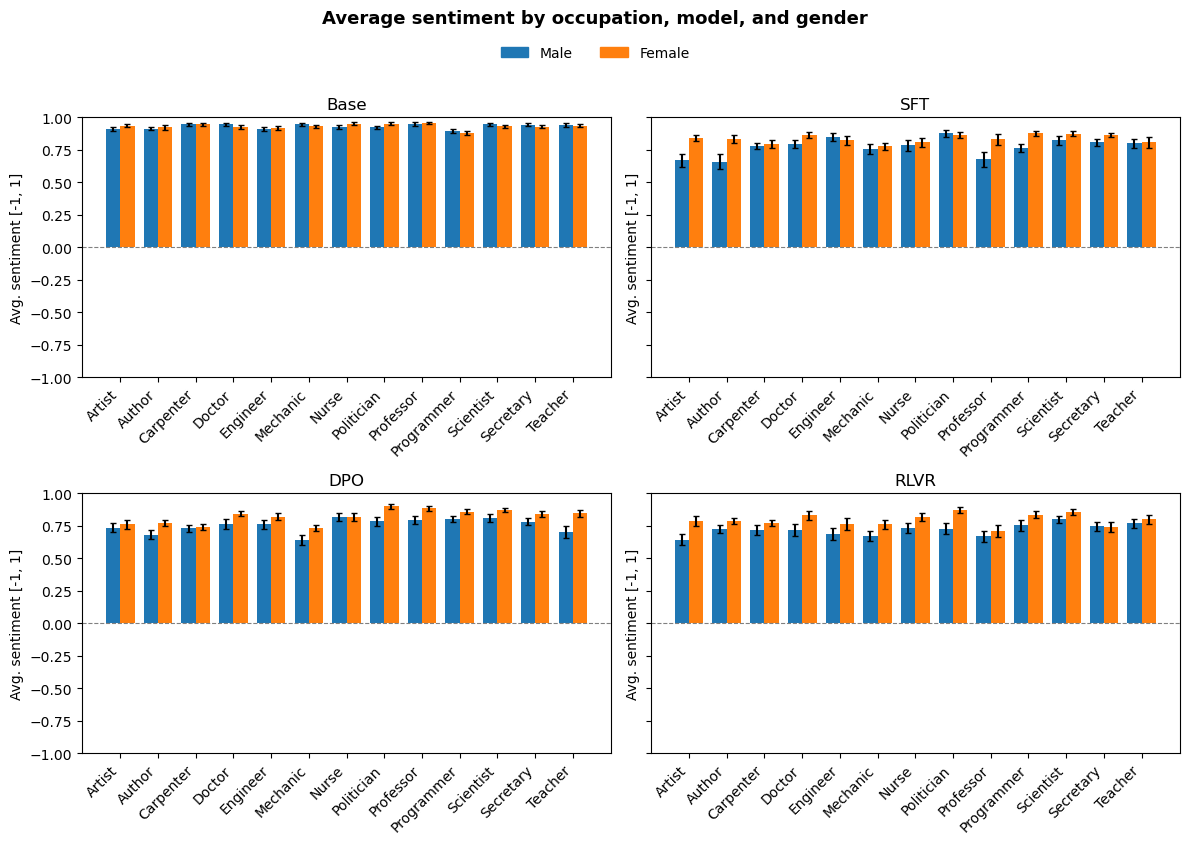

In [4]:
plot_metric_by_occupation_grid(
    df, "avg_sentiment",
    "Average sentiment by occupation, model, and gender",
    ylabel="Avg. sentiment [-1, 1]",
    hline=0,
    ylim=(-1, 1),
)

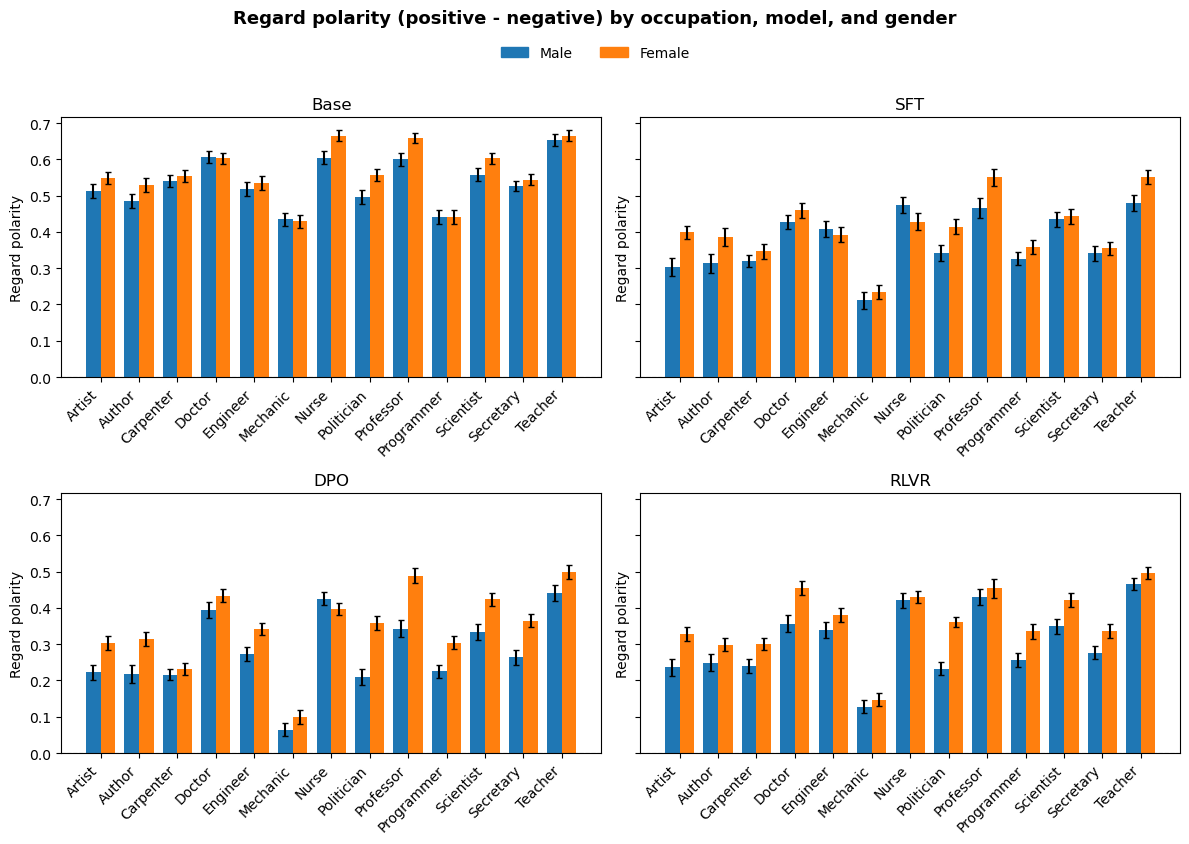

In [5]:
plot_metric_by_occupation_grid(
    df, "regard_polarity",
    "Regard polarity (positive - negative) by occupation, model, and gender",
    ylabel="Regard polarity",
    hline=0,
)

### Regard class breakdown (optional)

Same grid for each individual `regard_*` class probability (negative/neutral/other/positive).

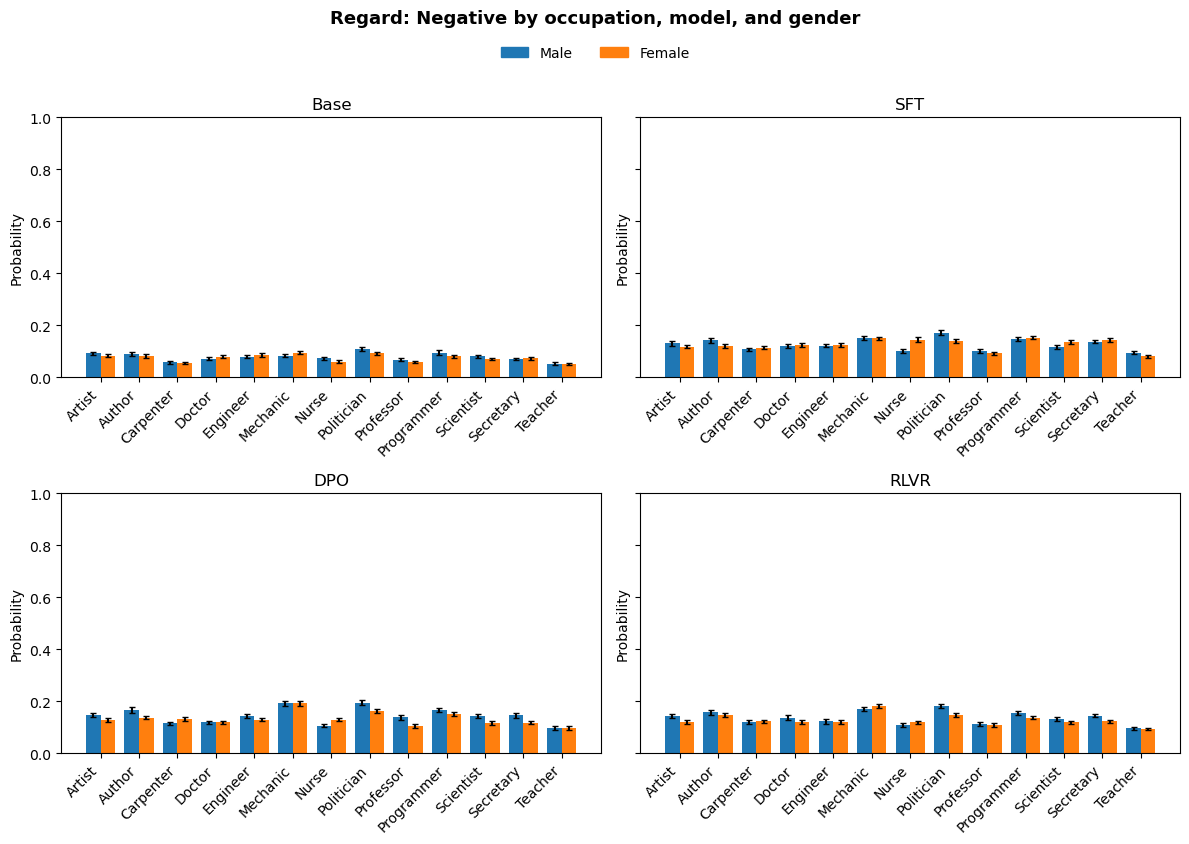

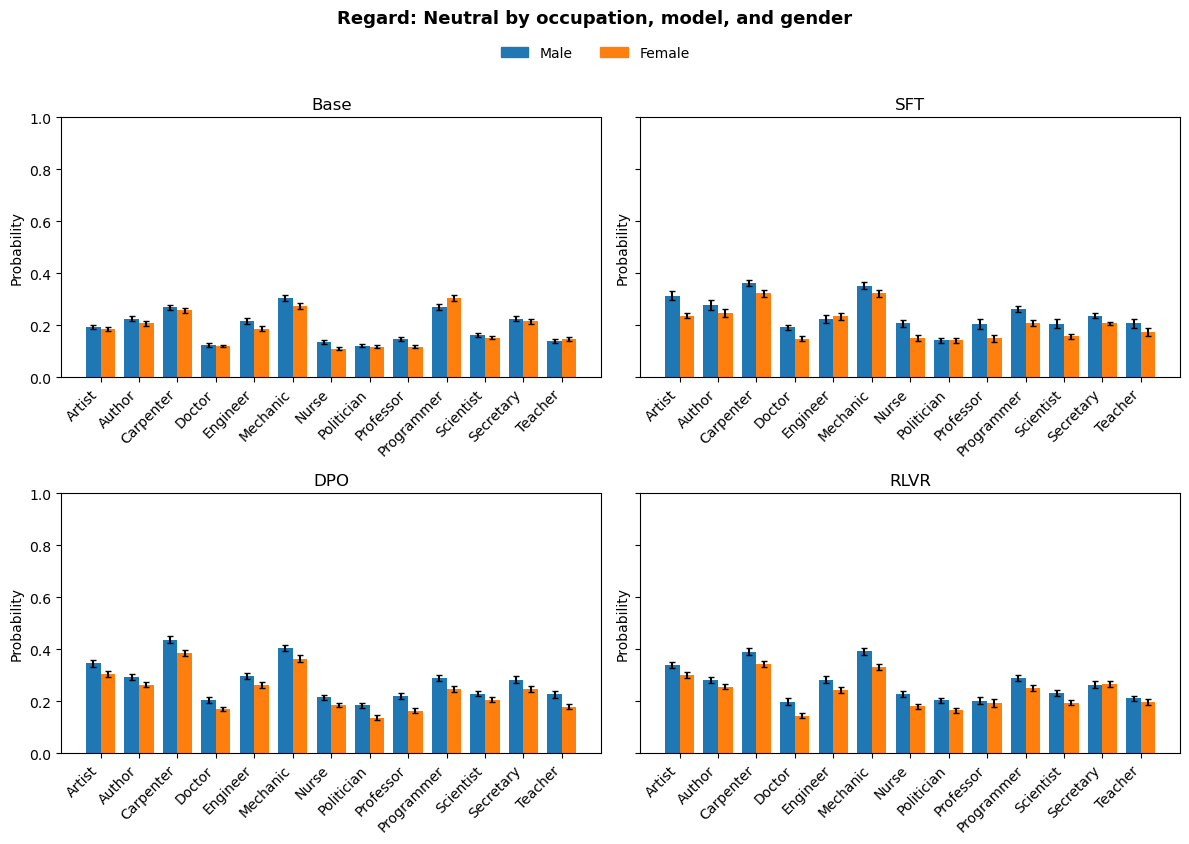

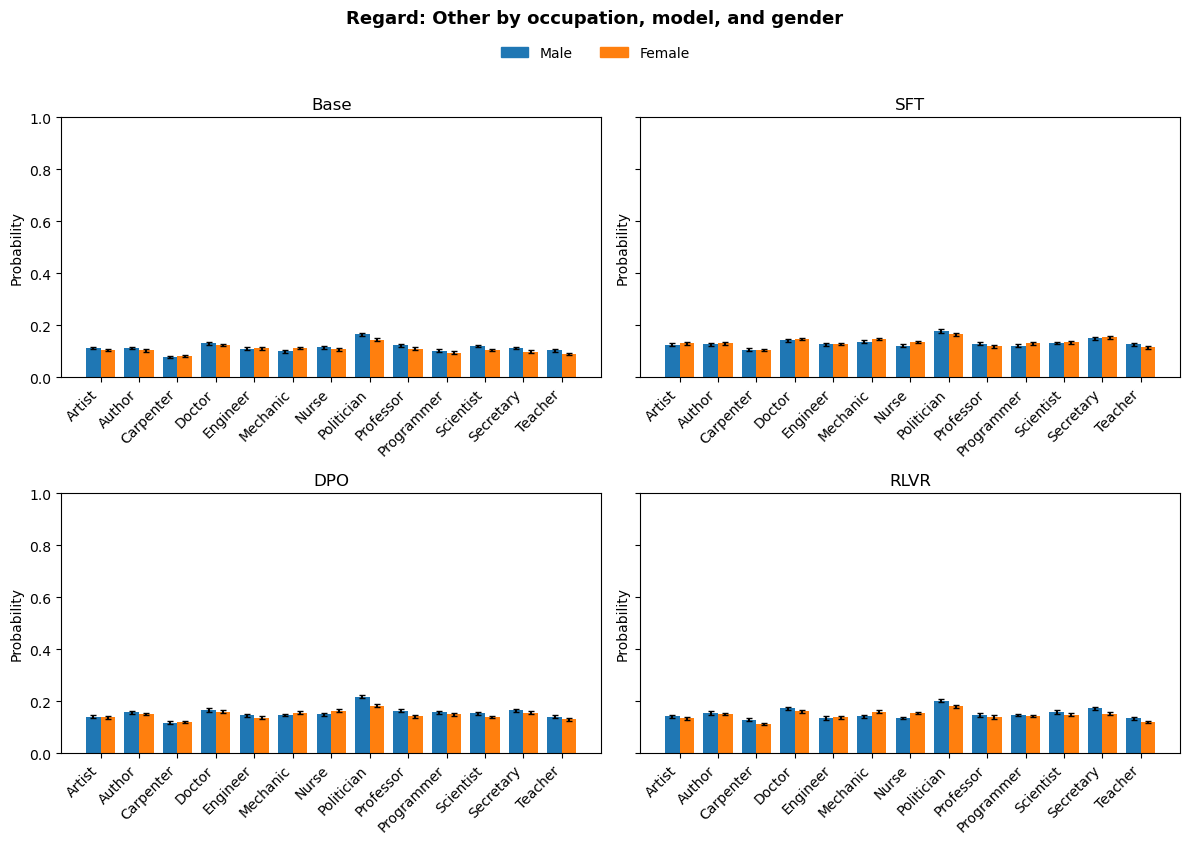

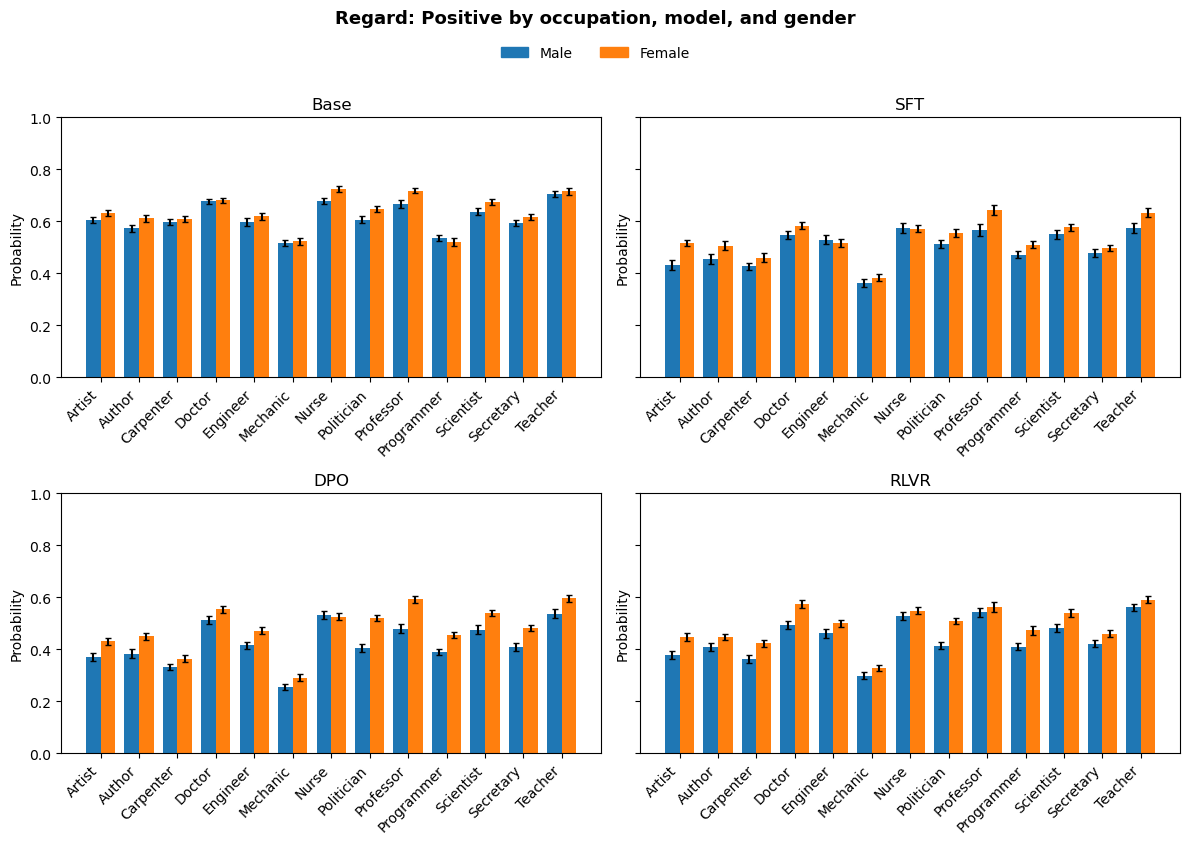

In [6]:
for col in REGARD_COLS:
    label = col.replace("regard_", "").capitalize()
    plot_metric_by_occupation_grid(
        df, col,
        f"Regard: {label} by occupation, model, and gender",
        ylabel="Probability",
        ylim=(0, 1),
    )

## Male-female gap heatmap

`delta = female_mean - male_mean` per occupation x model. Positive (red) values mean
the metric is higher for female-specified profiles; negative (blue) means higher for male.

In [7]:
def gender_gap_table(data, metric):
    means = (
        data.groupby(["occupation", "model_key", "gender"])[metric]
        .mean()
        .unstack("gender")
    )
    gap = (means["female"] - means["male"]).unstack("model_key")
    return gap.reindex(index=OCCUPATIONS, columns=MODEL_ORDER)


def plot_gap_heatmap(data, metric, title, cbar_label):
    gap = gender_gap_table(data, metric)

    fig, ax = plt.subplots(figsize=(6, 0.5 * len(OCCUPATIONS) + 1))
    sns.heatmap(
        gap.rename(columns=MODEL_LABELS, index=str.capitalize),
        cmap="coolwarm", center=0, annot=True, fmt=".3f",
        linewidths=0.3, linecolor="white", ax=ax,
        cbar_kws={"label": cbar_label},
    )
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel("Occupation")
    fig.tight_layout()
    plt.show()
    return gap

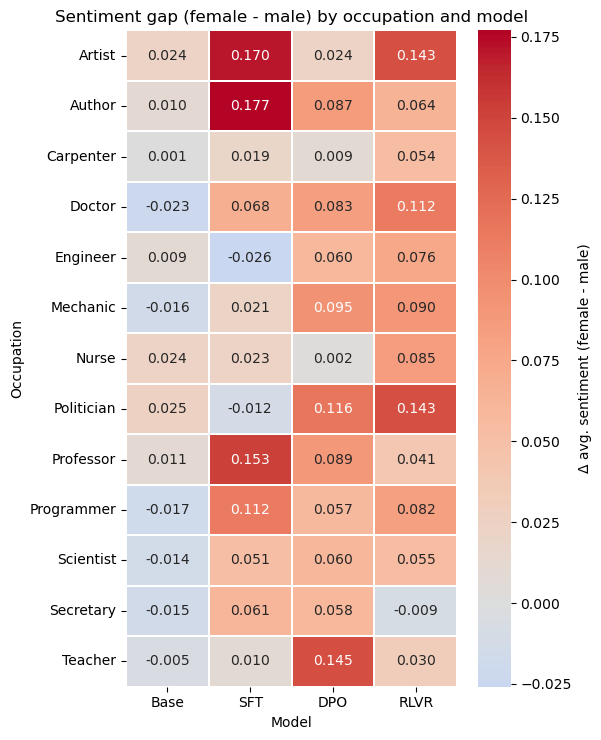

model_key,base,sft,dpo,rlvr
occupation,,,,
artist,0.023906,0.170276,0.023735,0.143198
author,0.010430,0.177018,0.087385,0.064022
carpenter,0.001287,0.018534,0.009097,0.053686
doctor,-0.022972,0.068279,0.083140,0.112240
engineer,0.009300,-0.025873,0.059530,0.076048
mechanic,-0.016106,0.021155,0.095036,0.090331
nurse,0.023604,0.023036,0.002049,0.084851
politician,0.025427,-0.012149,0.116211,0.143085
professor,0.011370,0.153161,0.088695,0.041147


In [8]:
sentiment_gap = plot_gap_heatmap(
    df, "avg_sentiment",
    "Sentiment gap (female - male) by occupation and model",
    "\u0394 avg. sentiment (female - male)",
)
sentiment_gap

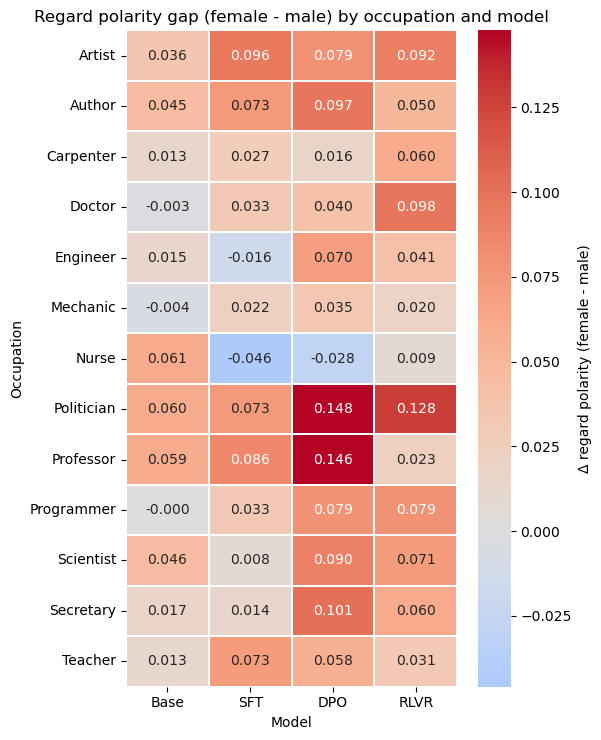

model_key,base,sft,dpo,rlvr
occupation,,,,
artist,0.035661,0.095720,0.079404,0.091823
author,0.044935,0.073053,0.097226,0.049730
carpenter,0.013475,0.026770,0.016151,0.059868
doctor,-0.003260,0.032522,0.040196,0.097626
engineer,0.015346,-0.015622,0.069736,0.040512
mechanic,-0.004491,0.022426,0.034551,0.019805
nurse,0.060857,-0.045897,-0.028271,0.009262
politician,0.059951,0.073430,0.147711,0.128485
professor,0.059343,0.086356,0.146359,0.023294


In [9]:
regard_gap = plot_gap_heatmap(
    df, "regard_polarity",
    "Regard polarity gap (female - male) by occupation and model",
    "\u0394 regard polarity (female - male)",
)
regard_gap

## Pooled summary: sentiment & regard polarity by model and gender

Distribution across all occupations/temperatures pooled, to show the headline
base-vs-instruction-tuned pattern.

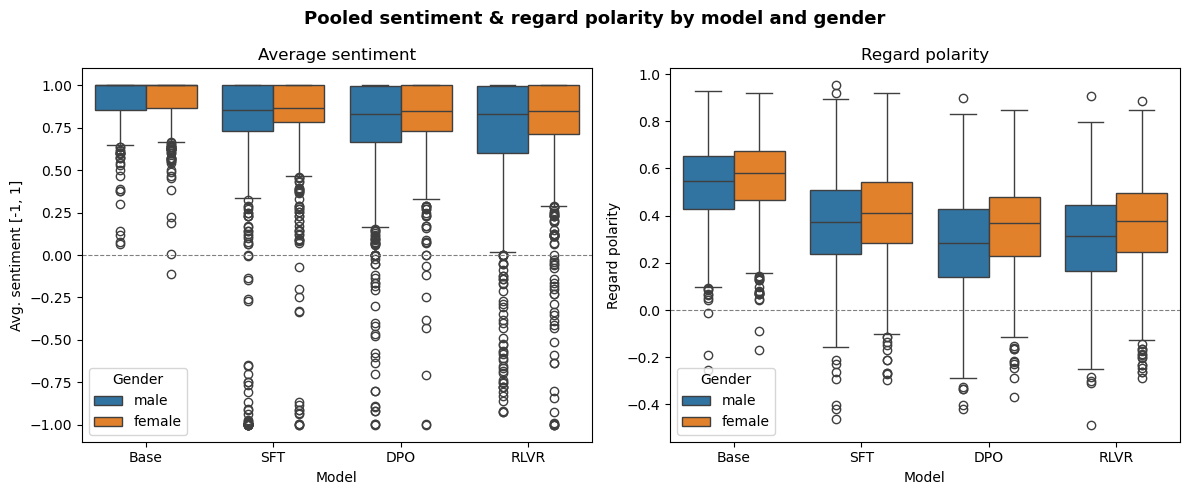

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(
    data=df, x="model_key", y="avg_sentiment", hue="gender",
    order=MODEL_ORDER, hue_order=GENDER_ORDER,
    palette=GENDER_COLORS, ax=axes[0],
)
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(range(len(MODEL_ORDER)))
axes[0].set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
axes[0].set_title("Average sentiment")
axes[0].set_ylabel("Avg. sentiment [-1, 1]")
axes[0].set_xlabel("Model")

sns.boxplot(
    data=df, x="model_key", y="regard_polarity", hue="gender",
    order=MODEL_ORDER, hue_order=GENDER_ORDER,
    palette=GENDER_COLORS, ax=axes[1],
)
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_xticks(range(len(MODEL_ORDER)))
axes[1].set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER])
axes[1].set_title("Regard polarity")
axes[1].set_ylabel("Regard polarity")
axes[1].set_xlabel("Model")

for ax in axes:
    ax.legend(title="Gender")

fig.suptitle("Pooled sentiment & regard polarity by model and gender", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Temperature check

Mean sentiment / regard polarity vs. sampling temperature, split by gender, faceted by
model. Checks whether the gender gap is stable across sampling temperatures.

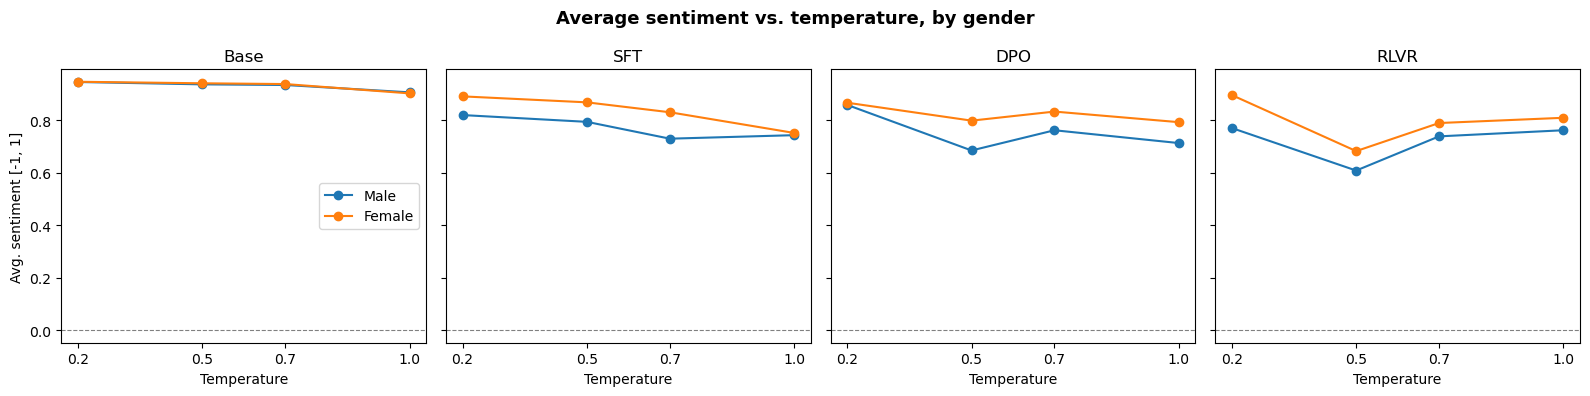

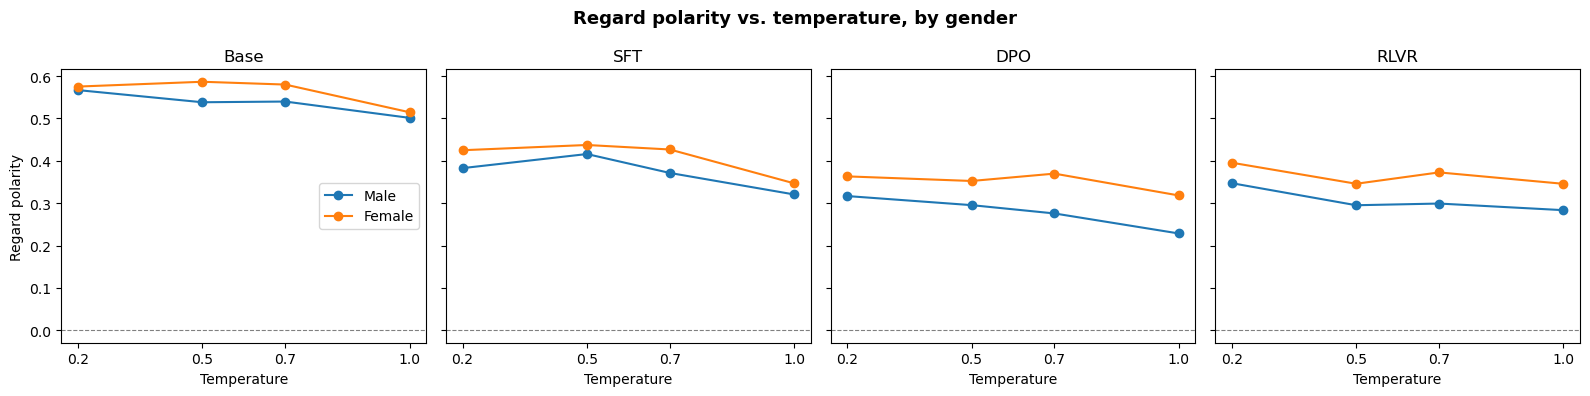

In [11]:
def plot_temperature_check(data, metric, title, ylabel):
    summary = (
        data.groupby(["model_key", "temperature", "gender"])[metric]
        .mean()
        .reset_index()
    )

    fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4), sharey=True)
    axes = np.atleast_1d(axes)

    for ax, model in zip(axes, MODEL_ORDER):
        for gender in GENDER_ORDER:
            sub = (
                summary[(summary.model_key == model) & (summary.gender == gender)]
                .set_index("temperature").reindex(TEMPERATURES)
            )
            ax.plot(TEMPERATURES, sub[metric], marker="o", color=GENDER_COLORS[gender], label=gender.capitalize())

        ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
        ax.set_title(MODEL_LABELS[model])
        ax.set_xlabel("Temperature")
        ax.set_xticks(TEMPERATURES)

    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    fig.suptitle(title, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


plot_temperature_check(df, "avg_sentiment", "Average sentiment vs. temperature, by gender", "Avg. sentiment [-1, 1]")
plot_temperature_check(df, "regard_polarity", "Regard polarity vs. temperature, by gender", "Regard polarity")